In [1]:
%pip install numpy
%pip install matplotlib
%pip install scikit-learn
%pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


    amaranth-yosys (>=0.10.*) ; extra == 'builtin-yosys'
                    ~~~~~~~^

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


    amaranth-yosys (>=0.10.*) ; extra == 'builtin-yosys'
                    ~~~~~~~^

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


    amaranth-yosys (>=0.10.*) ; extra == 'builtin-yosys'
                    ~~~~~~~^

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


    amaranth-yosys (>=0.10.*) ; extra == 'builtin-yosys'
                    ~~~~~~~^

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Classification
---
## Step 1: Observe Data

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# rice_dataset_raw becomes a dataframe

rice_dataset_raw = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/Rice_Cammeo_Osmancik.csv")

# double list to return as a 2D dataframe
rice_dataset = rice_dataset_raw[[
    'Area',
    'Perimeter',
    'Major_Axis_Length',
    'Minor_Axis_Length',
    'Eccentricity',
    'Convex_Area',
    'Extent',
    'Class',
]]

# pandas automatically desribe csv with .describe() method
rice_dataset.describe()
# print(rice_dataset)

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
count,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000
mean,12667.727559,454.239180,188.776222,86.313750,0.886871,12952.496850,0.661934
std,1732.367706,35.597081,17.448679,5.729817,0.020818,1776.972042,0.077239
min,7551.000000,359.100006,145.264465,59.532406,0.777233,7723.000000,0.497413
25%,11370.500000,426.144753,174.353855,82.731695,0.872402,11626.250000,0.598862
50%,12421.500000,448.852493,185.810059,86.434647,0.889050,12706.500000,0.645361
75%,13950.000000,483.683746,203.550438,90.143677,0.902588,14284.000000,0.726562
max,18913.000000,548.445984,239.010498,107.542450,0.948007,19099.000000,0.861050


Text(0, 0.5, 'Ext')

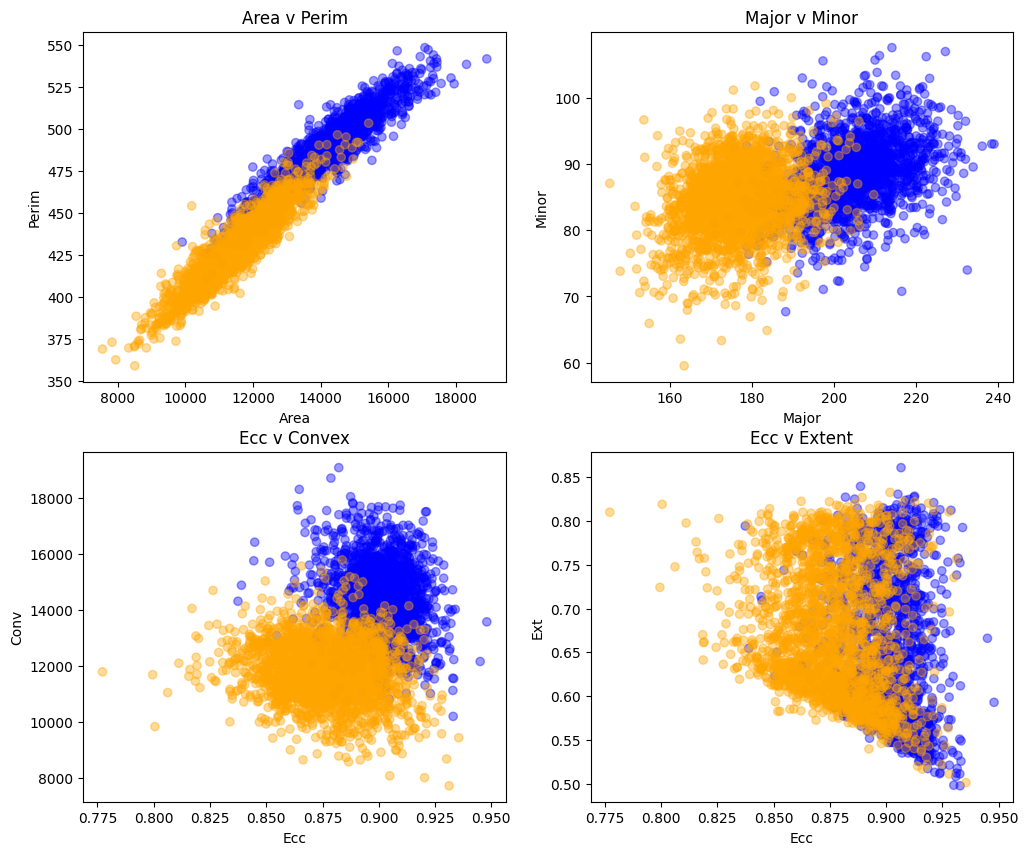

In [46]:
colors_1 = rice_dataset['Class'].map({'Cammeo': 'blue', 'Osmancik': 'orange'})

fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(12,10))

# area v perimeter
axes[0, 0].scatter(rice_dataset['Area'], rice_dataset['Perimeter'], c=colors_1, alpha=0.4)
axes[0, 0].set_title("Area v Perim")
axes[0, 0].set_xlabel("Area")
axes[0, 0].set_ylabel("Perim")

# eccentricity v convex
axes[1, 0].scatter(rice_dataset['Eccentricity'], rice_dataset['Convex_Area'], c=colors_1, alpha=0.4)
axes[1, 0].set_title("Ecc v Convex")
axes[1, 0].set_xlabel("Ecc")
axes[1, 0].set_ylabel("Conv")

# major v minor
axes[0, 1].scatter(rice_dataset['Major_Axis_Length'], rice_dataset['Minor_Axis_Length'], c=colors_1, alpha=0.4)
axes[0, 1].set_title("Major v Minor")
axes[0, 1].set_xlabel("Major")
axes[0, 1].set_ylabel("Minor")

# Ecc v extent
axes[1, 1].scatter(rice_dataset['Eccentricity'], rice_dataset['Extent'], c=colors_1, alpha=0.4)
axes[1, 1].set_title("Ecc v Extent")
axes[1, 1].set_xlabel("Ecc")
axes[1, 1].set_ylabel("Ext")

Text(0.5, 1.0, 'Perimeter')

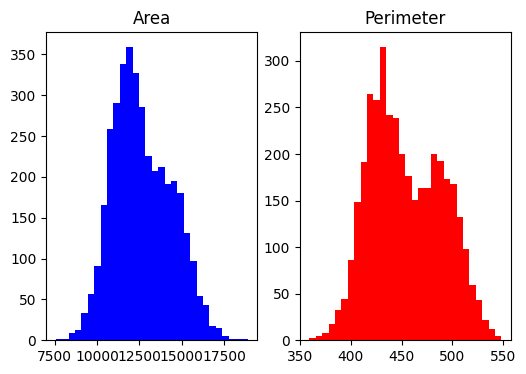

In [42]:

fig_his, axes_his = plt.subplots(nrows=1, ncols=2, figsize=(6, 4))
axes_his[0].hist(rice_dataset['Area'],bins=30, color="blue")
axes_his[0].set_title("Area")

axes_his[1].hist(rice_dataset['Perimeter'],bins=30, color="red")
axes_his[1].set_title("Perimeter")


# Normalization

We use Z-scaling, which is good for normal distributed graphs.

### Z-scaling Formula
---
$$
x' = \frac{(x - μ)}{σ}
$$
where:
- $x^{'}$ is the Z-score
- $x$ is the raw value; that is, $x$ is the value you are normalizing.
- $μ$ is the mean.
- $σ$ is the standard deviation.

In [58]:

# this returns data of only the numerical features (not class since its value is a string)
numerical_features = rice_dataset.select_dtypes('number')

z_score = (numerical_features - numerical_features.mean()) / numerical_features.std()

z_score.describe()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
count,3.810000e+03,3.810000e+03,3.810000e+03,3.810000e+03,3.810000e+03,3.810000e+03,3.810000e+03
mean,5.967813e-17,-1.790344e-15,-1.074206e-15,1.491953e-16,2.924228e-15,-5.371032e-16,1.790344e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-2.953604e+00,-2.672668e+00,-2.493699e+00,-4.674031e+00,-5.266589e+00,-2.942926e+00,-2.130034e+00
25%,-7.488177e-01,-7.892340e-01,-8.265593e-01,-6.251605e-01,-6.950351e-01,-7.463521e-01,-8.165818e-01
50%,-1.421335e-01,-1.513238e-01,-1.699936e-01,2.109949e-02,1.046992e-01,-1.384360e-01,-2.145634e-01
75%,7.401849e-01,8.271624e-01,8.467241e-01,6.684203e-01,7.550077e-01,7.493101e-01,8.367238e-01
max,3.605050e+00,2.646475e+00,2.878973e+00,3.704952e+00,2.936761e+00,3.458976e+00,2.577922e+00


Text(0.5, 1.0, 'Original')

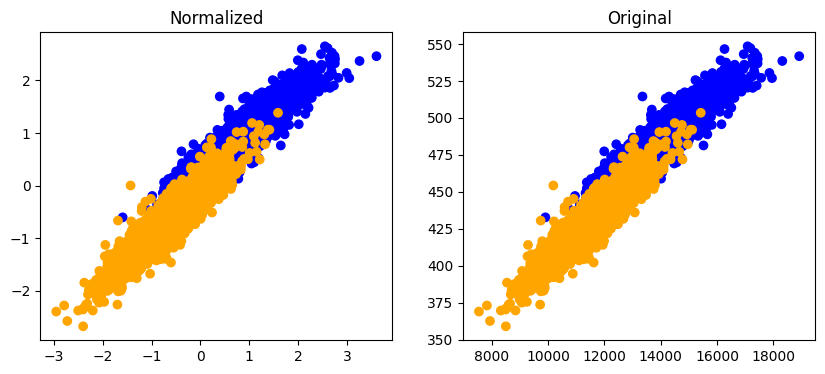

In [65]:
# ensure data is normalized correctly

fig_normal, axes_normal = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

axes_normal[0].scatter(z_score['Area'], z_score['Perimeter'], c=colors_1)
axes_normal[0].set_title("Normalized")

axes_normal[1].scatter(rice_dataset['Area'], rice_dataset['Perimeter'], c=colors_1)
axes_normal[1].set_title("Original")

# Log Loss

Log Loss equation returns the logarithm of the magnitude of the change, rather than just the distance from data to prediction (Loss from Linear Regression).
$$
\text{Log Loss} = -\frac{1}{N}\sum_{i=1}^{N} y_i\log(y_i') + (1 - y_i)\log(1 - y_i')
$$
Where:
- $N$ is the number of the labeled examples in the dataset.
- $i$ is the index of an example in the dataset (e.g., $(x_3,y_3)$ is the **THIRD** example in the dataset).
- $y_i$ is the label for the $i$th example. Since this is logistic expression, $y_i$ must be either 0 or 1.
-  $y'_i$ is the logistic regression prediction:
$$
y' = \frac{1}{1+e^{-z}}
$$

Where $z$ is:
$$
z = b + w_1x_1 + w_2x_2 + \ldots + w_Nx_N
$$

## Log Loss Gradients

- Weights:
$$
\frac{\partial L}{\partial w} = \frac{1}{N} \sum (\hat{y} - y) \cdot x
$$
- Bias:
$$
\frac{\partial L}{\partial b} = \frac{1}{N} \sum (\hat{y} - y)
$$

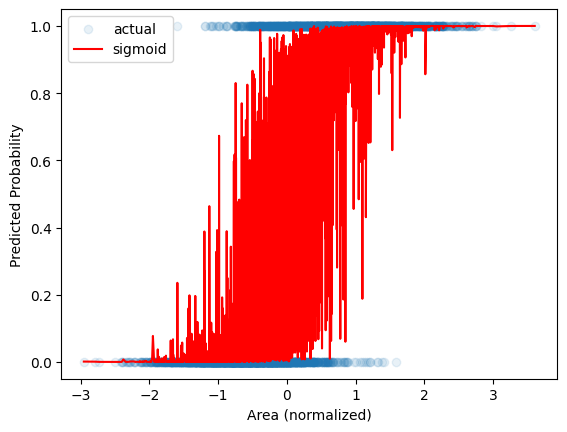

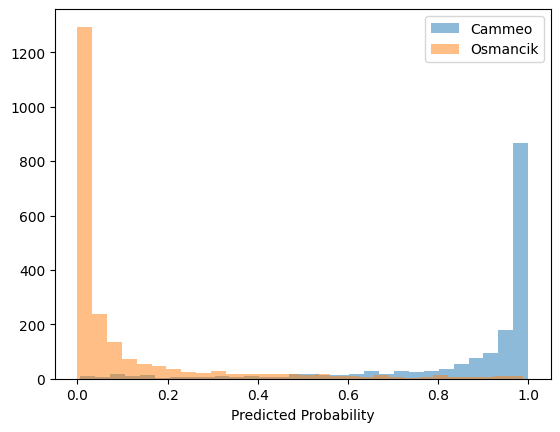

In [ ]:
import numpy as np


# X will be our features [Area, Perimeter, ...]
X = z_score.values

# Cammeo = positive class (1), Osmancik = negative class (0)
# y will be our targets/labels (rice classification)
y = (rice_dataset['Class'] == 'Cammeo').astype(int).values

epochs = 10000
learning_rate = 0.005

weights, bias = np.zeros(X.shape[1]), 0

def logistic_regression(epochs, learning_rate, weights, bias):
    N = len(X)
    for _ in range(epochs):
        # @ is the matrix operator
        # get current z
        z = bias + X @ weights

        y_pred = 1 / (1 + np.exp(-z))

        # transpose matrix for matrix multiplication
        dw = 1/N * (X.T @ (y_pred - y))
        db = 1/N * np.sum(y_pred - y)

        # update weights and biases according to gradient
        weights -= dw * learning_rate
        bias -= db * learning_rate
    
    z_final = bias + X @ weights
    y_pred_final = 1 / (1 + np.exp(-z_final))

    return y_pred_final

y_pred_final = logistic_regression(epochs, learning_rate, weights, bias)

# 0th column is the area
sorted_idx = X[:, 0].argsort()

plt.scatter(X[:, 0], y, alpha=0.1, label='actual')                             
plt.plot(X[sorted_idx, 0], y_pred_final[sorted_idx], c='red', label='sigmoid') 
plt.xlabel('Area (normalized)')
plt.ylabel('Predicted Probability')
plt.legend()
plt.show()

plt.hist(y_pred_final[y == 1], bins=30, alpha=0.5, label='Cammeo')
plt.hist(y_pred_final[y == 0], bins=30, alpha=0.5, label='Osmancik')
plt.xlabel('Predicted Probability')
plt.legend()
plt.show()

## Accuracy
---
Accuracy is the proportion of all classifications that were correct, whether positive or negative. It's defined as:
$$
\text{Accuracy} =\frac{\text{correct classifications}}{\text{total classifications}}= \frac{TP+TN}{TP+TN+FP+FN}
$$
In the spam classification example, accuracy measures the fraction of all emails correctly classified.
A perfect model would have zero false or positive negatives. Thus we would have an accuracy of 1.0 or 100%.
Accuracy can serve as to measure the model quality. If a dataset is imbalanced its better to optimize for one of the other metrics instead.

In [ ]:
threshold = 0.5  # change this to any value

y_pred_class = (y_pred_final >= threshold).astype(int)

# false postive: predicted positive but actually negative
fp_mask = (y_pred_class == 1) & (y == 0)

# false negative: predicted negative by actually positive
fn_mask = (y_pred_class == 0) & (y == 1)

print(f"Threshold: {threshold}")
print(f"False Positives: {fp_mask.sum()}")
print(f"False Negatives: {fn_mask.sum()}")



Threshold: 0.5
False Positives: 140
False Negatives: 133


In [ ]:
# since Cammeo = positive class (1), Osmancik = negative class (0)

# this returns the true pos/neg
ap_mask = ((y_pred_class == 1) & (y == 1)).sum()
an_mask = ((y_pred_class == 0) & (y == 0)).sum()

print(f"Threshold: {threshold}")
print(f"Actual Positives: {ap_mask.sum()}")
print(f"Actual Negatives: {an_mask.sum()}")

Threshold: 0.5
Actual Positives: 1497
Actual Negatives: 2040


In [ ]:
TP = ((y_pred_class == 1) & (y == 1)).sum()
TN = ((y_pred_class == 0) & (y == 0)).sum()
FP = ((y_pred_class == 1) & (y == 0)).sum()
FN = ((y_pred_class == 0) & (y == 1)).sum()

# len(y) total classifications
accuracy = (TP + TN) / len(y)

print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")
print(f"Accuracy: {accuracy:.4f}")


TP: 1497, TN: 2040, FP: 140, FN: 133
Accuracy: 0.9283


# Playground

TP: 1449, TN: 2085, FP: 95, FN: 181
Accuracy: 0.9276


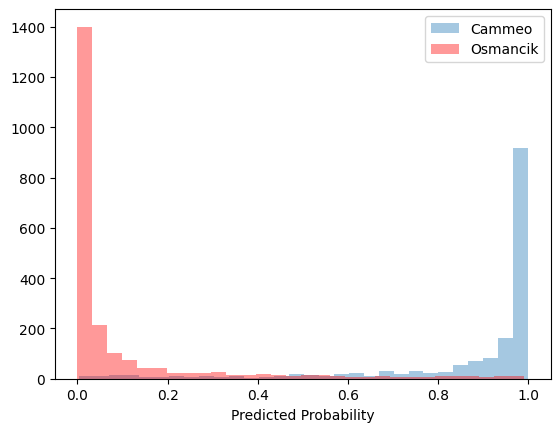

In [ ]:

nepochs = 100_000
nlearning_rate = 0.005
nthreshold = 0.6

y_pred_final = logistic_regression(nepochs, nlearning_rate, weights, bias)
y_pred_class = (y_pred_final >= nthreshold).astype(int)

TP = ((y_pred_class == 1) & (y == 1)).sum()
TN = ((y_pred_class == 0) & (y == 0)).sum()
FP = ((y_pred_class == 1) & (y == 0)).sum()
FN = ((y_pred_class == 0) & (y == 1)).sum()

accuracy = (TP + TN) / len(y)

print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")
print(f"Accuracy: {accuracy:.4f}")

plt.hist(y_pred_final[y == 1], bins=30, alpha=0.4, label='Cammeo')
plt.hist(y_pred_final[y == 0], color="red", bins=30, alpha=0.4, label='Osmancik')
plt.xlabel('Predicted Probability')
plt.legend()
plt.show()